# Spectral Decomposition of Type 1 AGN Using FANTASY

## Project Objective

The objective of this project is to analyze Type 1 Active Galactic Nuclei (AGN) spectra using the FANTASY spectral fitting package.

The workflow follows the official FANTASY tutorial and includes:

- Reading SDSS spectra
- Galactic extinction correction
- Host galaxy fitting
- Spectral decomposition
- Broad and narrow emission line fitting
- Fe II and He I emission modeling
- Parameter tuning and model comparison

Three Type 1 AGN spectra are analyzed and compared.

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)

import numpy as np
import pandas as pd

import glob

In [2]:
from fantasy_agn.tools import read_sdss, read_text, read_gama_fits
from fantasy_agn.models import create_input_folder
from fantasy_agn.models import create_feii_model, create_model, create_tied_model, continuum, create_line, create_fixed_model

# Object A

This object was selected as a Type 1 AGN candidate based on the presence of broad Balmer emission lines.

The spectrum is processed following the FANTASY tutorial workflow.

In [3]:
s=read_sdss('object1.fits')


## Galactic Extinction and Host Galaxy Correction

The spectrum is corrected for Galactic extinction and the host galaxy contribution is estimated using the SDSS host fitting routine.

In [4]:
s.DeRedden()
s.CorRed()
s.fit_host_sdss()
s.restore()
s.fit_host_sdss(mask_host=True, custom=False)

Host contribution is negliglable
Host contribution is negliglable


## Observed Spectrum

The corrected spectrum is inspected before spectral decomposition.

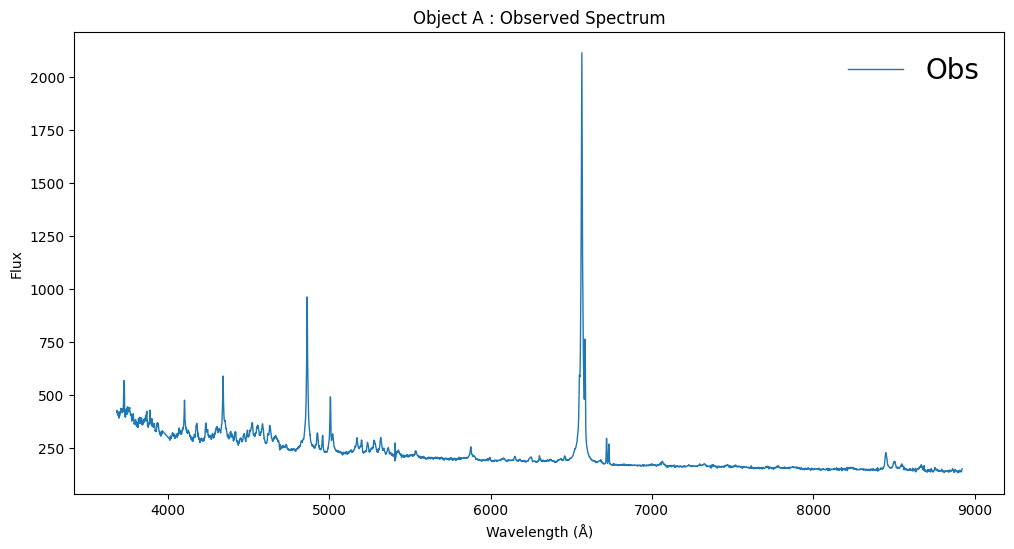

In [5]:
plt.figure(figsize=(12,6))

plt.plot(s.wave,s.flux,lw=1,label='Obs')
plt.legend(loc='upper right',  prop={'size': 20}, frameon=False, ncol=2)
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")

plt.title("Object A : Observed Spectrum")

plt.show()

## Input Files and Spectral Range Selection

Following the FANTASY tutorial, the spectrum is restricted to the wavelength range 4000–8000 Å.

This range contains the most important diagnostic emission lines while avoiding noisy spectral regions.

In [6]:
create_input_folder(xmin=4000,xmax=8000, path_to_folder='liness/')

Directory  liness/  already exists


In [7]:
s.crop(4000, 8000)

# Tutorial Model for Object 1

The first fit is performed using the default parameter configuration provided in the official FANTASY tutorial.

This model serves as the baseline model for comparison with later parameter tuning experiments.

In [8]:
cont=continuum(s,min_refer=5690, refer=5700, max_refer=5710)
broad=create_fixed_model(['hydrogen.csv'], name='br')
he=create_fixed_model(['helium.csv'], name='he',fwhm=3000, min_fwhm=1000, max_fwhm=5000)
narrow=create_tied_model(name='OIII5007',files=['narrow_basic.csv','hydrogen.csv'],prefix='nr', fwhm=1000,min_offset=0, max_offset=300, min_fwhm=900, max_fwhm=1200,fix_oiii_ratio=True, position=5006.803341, included=True,min_amplitude=0.2)
fe=create_feii_model(name='feii', fwhm=1800, min_fwhm=1000, max_fwhm=2000, offset=0, min_offset=-3000, max_offset=3000)
#fe.amp_b4p.min=10 #An example how to force the amplitude of a selected FeII multiplet.

model_tutorial = cont + broad + narrow + fe + he

## Tutorial Model Fit

The baseline model is fitted to the observed spectrum using the Levenberg-Marquardt optimization algorithm.

In [9]:
s.fit(model_tutorial, ntrial=2)

iteration:  1
iteration:  2


## Spectral Decomposition

The observed spectrum is decomposed into:

- Continuum
- Broad Hydrogen emission
- Narrow emission lines
- Broad Helium emission
- Fe II emission

The residual spectrum is also shown.

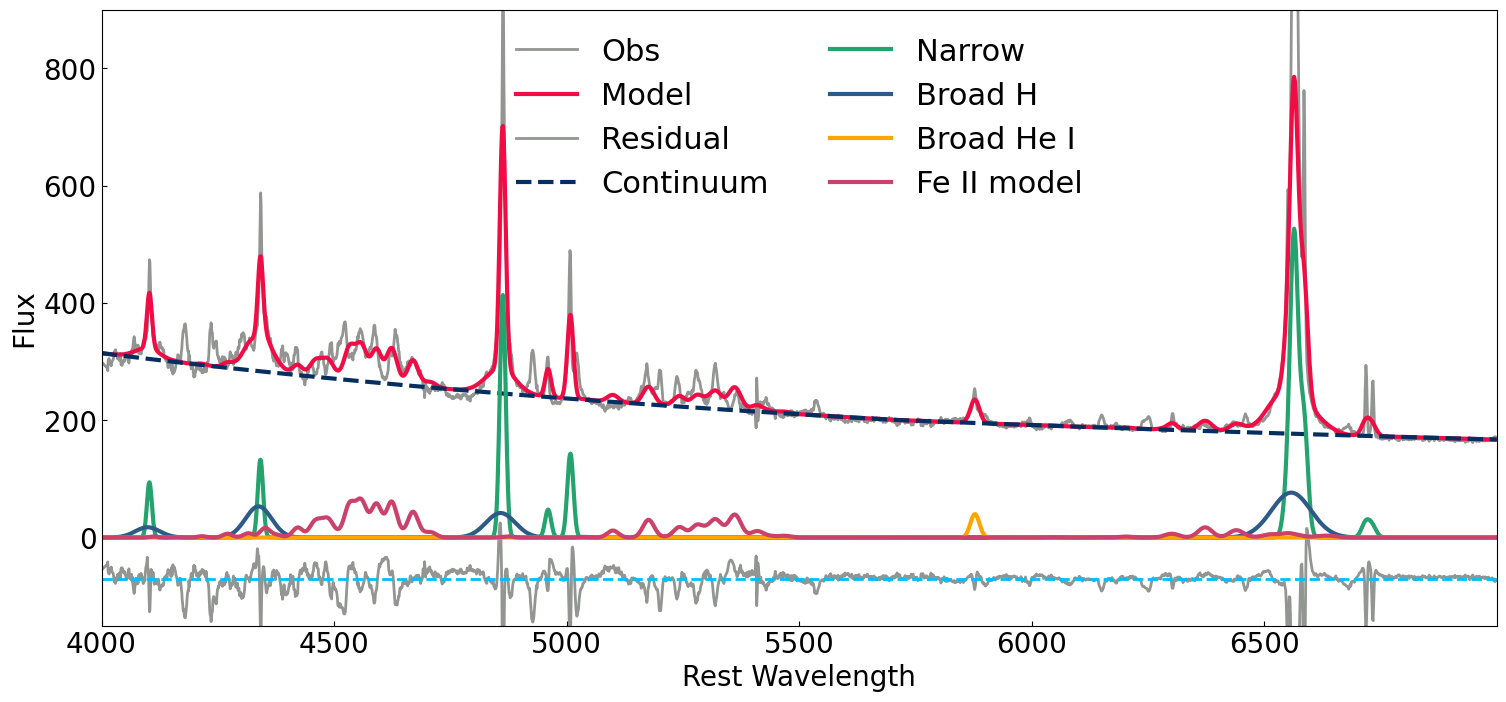

In [10]:
plt.style.context(['nature', 'notebook'])
plt.figure(figsize=(18,8))
plt.plot(s.wave, s.flux, color="#929591", label='Obs', lw=2)
plt.plot(s.wave, model_tutorial(s.wave), color="#F10C45",label='Model',lw=3)
plt.plot(s.wave, model_tutorial(s.wave)-s.flux-70, '-',color="#929591", label='Residual', lw=2)
plt.axhline(y=-70, color='deepskyblue', linestyle='--', lw=2)

plt.plot(s.wave, cont(s.wave),'--',color="#042E60",label='Continuum', lw=3)
plt.plot(s.wave, narrow(s.wave),label='Narrow',color="#25A36F",lw=3)
plt.plot(s.wave, broad(s.wave), label='Broad H', lw=3, color="#2E5A88")
plt.plot(s.wave, he(s.wave), label='Broad He I', lw=3, color="orange")
plt.plot(s.wave, fe(s.wave),'-',color="#CB416B",label='Fe II model', lw=3)

plt.xlabel('Rest Wavelength',fontsize=20)
plt.ylabel('Flux',fontsize=20)
plt.xlim(4000,7000)
plt.ylim(-150,900)
plt.tick_params(which='both', direction="in")
plt.yticks(fontsize=20)
plt.xticks(np.arange(4000, 7000, step=500),fontsize=20)
plt.legend(loc='upper center',  prop={'size': 22}, frameon=False, ncol=2)

plt.savefig('fantasy_object1.pdf')

## Tutorial Fit Results

The best-fit parameters obtained from the tutorial model are recorded for later comparison with the tuned model.

In [11]:
print(s.gres.format())

Method                = levmar
Statistic             = chi2
Initial fit statistic = 47330.2
Final fit statistic   = 47159.1 at function evaluation 927
Data points           = 3010
Degrees of freedom    = 2958
Probability [Q-value] = 0
Reduced statistic     = 15.9429
Change in statistic   = 171.062
   brokenpowerlaw.refer   5709.52      +/- 24.6838     
   brokenpowerlaw.ampl   200.478      +/- 0.889056    
   brokenpowerlaw.index1   -1.26409     +/- 0.00647347  
   brokenpowerlaw.index2   0.369622     +/- 0.00838019  
   br.amp_Hd_4102   17.5968      +/- 1.30383     
   br.amp_Hg_4340   53.2359      +/- 1.43924     
   br.amp_Hb_4861   41.921       +/- 1.07059     
   br.amp_Ha_6563   76.6189      +/- 1.47717     
   br.offs_kms    -200.077     +/- 20.5678     
   br.fwhm        4567.76      +/- 53.8734     
   nr_OIII5007.ampl   143.185      +/- 1.69629     
   nr_OIII5007.offs_kms   86.4399      +/- 2.04311     
   nr_OIII5007.fwhm   922.791      +/- 5.36039     
   nr_NII6584.ampl  

# Tuned Model for Object 1

The initial fit provided optimized parameter estimates for the broad hydrogen, helium, and Fe II components.

These values were used as improved starting parameters for a second fit in order to test whether the spectral decomposition could be improved.

The tuned model is compared against the baseline tutorial model.

In [12]:
cont = continuum(
    s,
    min_refer=5650,
    refer=5700,
    max_refer=5750
)

broad=create_fixed_model(
    ['hydrogen.csv'],
    name='br',
    fwhm=4500,
    min_fwhm=3000,
    max_fwhm=7000
)

he=create_fixed_model(
    ['helium.csv'],
    name='he',
    fwhm=1200,
    min_fwhm=500,
    max_fwhm=3000
)

narrow = create_tied_model(
    name='OIII5007',
    files=['narrow_basic.csv','hydrogen.csv'],
    prefix='nr',
    fwhm=1000,
    min_offset=0,
    max_offset=300,
    min_fwhm=900,
    max_fwhm=1200,
    fix_oiii_ratio=True,
    position=5006.803341,
    included=True,
    min_amplitude=0.2
)

fe=create_feii_model(
    name='feii',
    fwhm=1650,
    min_fwhm=1200,
    max_fwhm=2200,
    offset=0,
    min_offset=-3000,
    max_offset=3000
)

model_tuned = cont + broad + narrow + fe + he

In [13]:
model_tuned

<BinaryOpModel model instance 'brokenpowerlaw + br + nr_OIII5007 + nr_OIII4958 + nr_NII6584 + nr_NIII6548 + nr_[OIII]_4363 + nr_[OI]_6300 + nr_[OI]_6363 + nr_[SII]_6716 + nr_[SII]_6730 + nr_[OII]_7330 + nr_Hd_4101 + nr_Hg_4340 + nr_Hb_4861 + nr_Ha_6562 + feii + he'>

## Tuned Fit

The tuned model is fitted to the spectrum and compared with the baseline tutorial fit.

In [14]:
s.fit(model_tuned, ntrial=2)

iteration:  1
iteration:  2


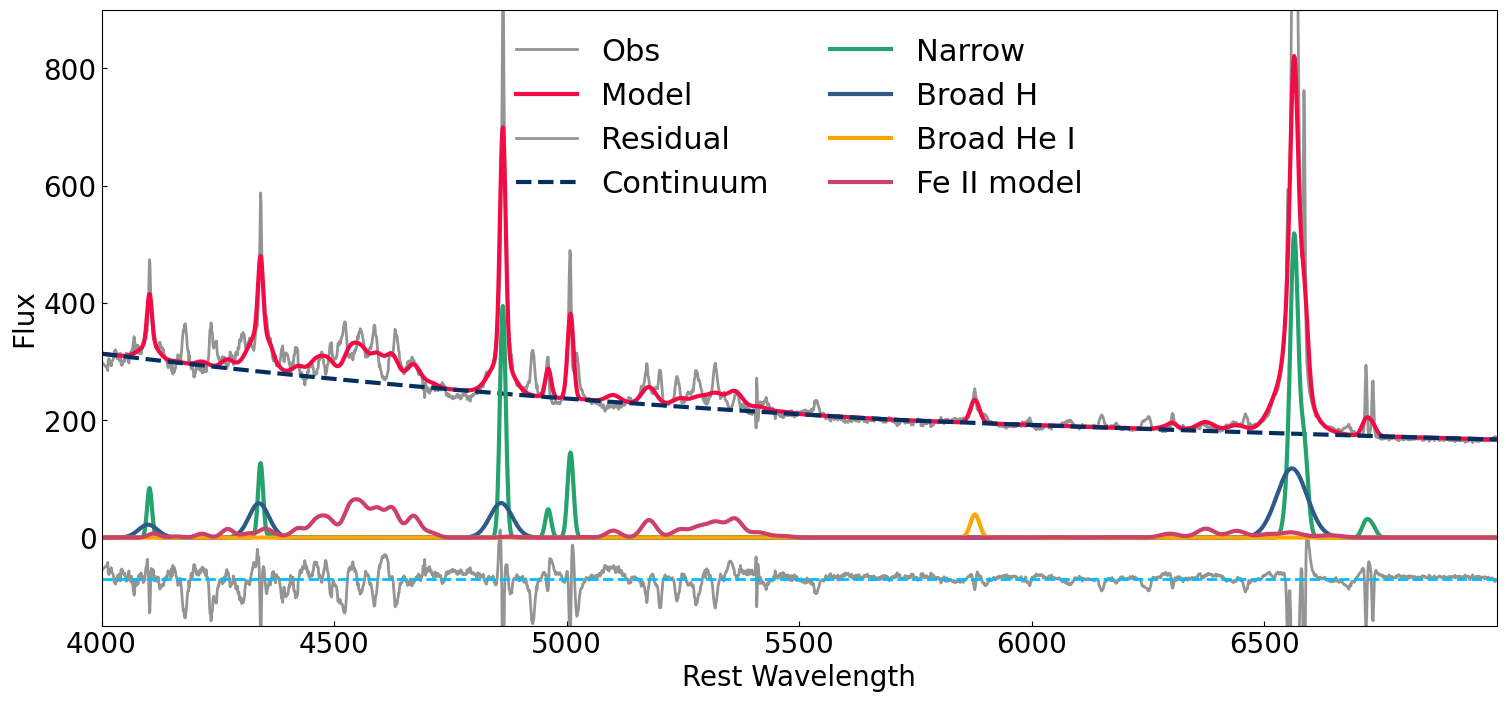

In [15]:
plt.style.context(['nature', 'notebook'])
plt.figure(figsize=(18,8))
plt.plot(s.wave, s.flux, color="#929591", label='Obs', lw=2)
plt.plot(s.wave, model_tuned(s.wave), color="#F10C45",label='Model',lw=3)
plt.plot(s.wave, model_tuned(s.wave)-s.flux-70, '-',color="#929591", label='Residual', lw=2)
plt.axhline(y=-70, color='deepskyblue', linestyle='--', lw=2)

plt.plot(s.wave, cont(s.wave),'--',color="#042E60",label='Continuum', lw=3)
plt.plot(s.wave, narrow(s.wave),label='Narrow',color="#25A36F",lw=3)
plt.plot(s.wave, broad(s.wave), label='Broad H', lw=3, color="#2E5A88")
plt.plot(s.wave, he(s.wave), label='Broad He I', lw=3, color="orange")
plt.plot(s.wave, fe(s.wave),'-',color="#CB416B",label='Fe II model', lw=3)

plt.xlabel('Rest Wavelength',fontsize=20)
plt.ylabel('Flux',fontsize=20)
plt.xlim(4000,7000)
plt.ylim(-150,900)
plt.tick_params(which='both', direction="in")
plt.yticks(fontsize=20)
plt.xticks(np.arange(4000, 7000, step=500),fontsize=20)
plt.legend(loc='upper center',  prop={'size': 22}, frameon=False, ncol=2)

plt.savefig('fantasy_object1_fit.pdf')

In [16]:
print(s.gres.format())

Method                = levmar
Statistic             = chi2
Initial fit statistic = 46019.1
Final fit statistic   = 45900.4 at function evaluation 927
Data points           = 3010
Degrees of freedom    = 2958
Probability [Q-value] = 0
Reduced statistic     = 15.5174
Change in statistic   = 118.735
   brokenpowerlaw.refer   5708.58      +/- 26.9543     
   brokenpowerlaw.ampl   200.678      +/- 0.963354    
   brokenpowerlaw.index1   -1.25383     +/- 0.00666742  
   brokenpowerlaw.index2   0.356581     +/- 0.00862804  
   br.amp_Hd_4102   22.03        +/- 1.62737     
   br.amp_Hg_4340   58.4199      +/- 1.75763     
   br.amp_Hb_4861   58.8846      +/- 1.47562     
   br.amp_Ha_6563   117.955      +/- 2.35776     
   br.offs_kms    -133.863     +/- 15.3793     
   br.fwhm        3493.83      +/- 37.428      
   nr_OIII5007.ampl   145.062      +/- 1.73756     
   nr_OIII5007.offs_kms   102.984      +/- 2.14557     
   nr_OIII5007.fwhm   900.898      +/- 5.86399     
   nr_NII6584.ampl  

# Model Comparison

The tutorial model and tuned model are compared using the reduced chi-square statistic.

A lower reduced chi-square indicates a better description of the observed spectrum.

| Model | Reduced χ² |
|---------|---------|
| Tutorial Model | 15.94 |
| Tuned Model | 15.51 |

The tuned model produced a lower reduced χ² value and was therefore adopted as the preferred solution for Object A.

# Physical Interpretation

The fitted spectrum shows:

- Strong broad Balmer emission lines
- Significant Fe II emission
- Broad He I emission
- Narrow forbidden emission lines

The broad Hβ component has a FWHM of approximately 4568 km/s, confirming the Type 1 AGN classification.

The presence of Fe II and He I emission further supports the active nature of the nucleus.

# Object B 

This object was selected as a second Type 1 AGN candidate.

The same FANTASY workflow used for Object A is applied here in order to compare the spectral properties of different AGN.

In [17]:
s2 = read_sdss("object2.fits")

## Galactic Extinction and Host Galaxy Correction

The spectrum is corrected for Galactic extinction and host galaxy contamination before spectral fitting.

In [18]:
s2.DeRedden()
s2.CorRed()

s2.fit_host_sdss()

s2.restore()

s2.fit_host_sdss(mask_host=True, custom=False)

Host contribution is negliglable
Host contribution is negliglable


## Observed Spectrum

The corrected spectrum is inspected before decomposition.

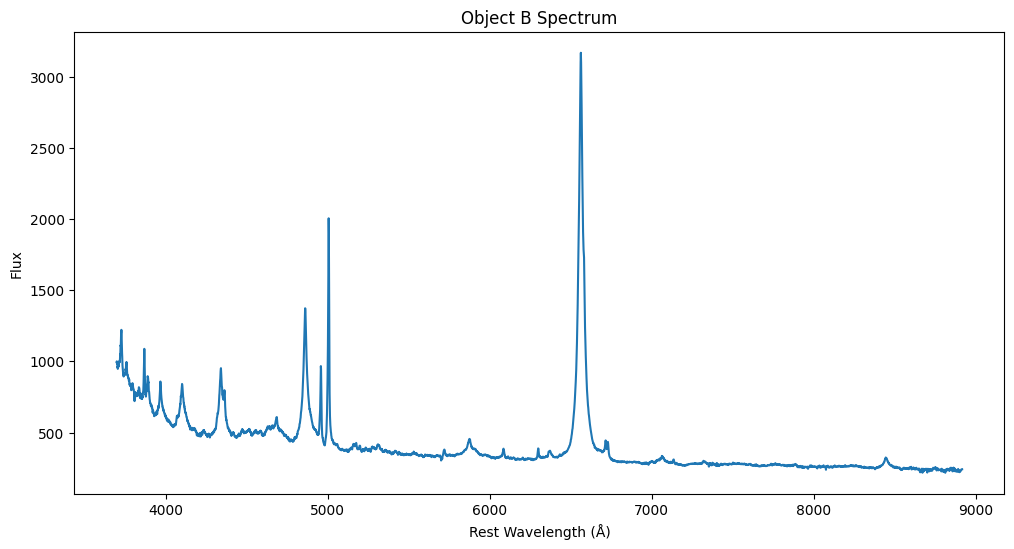

In [19]:
plt.figure(figsize=(12,6))

plt.plot(s2.wave, s2.flux)

plt.xlabel("Rest Wavelength (Å)")
plt.ylabel("Flux")

plt.title("Object B Spectrum")

plt.show()

## Spectral Range Selection

The spectrum is restricted to the wavelength range used throughout the FANTASY tutorial.

In [20]:
create_input_folder(
    xmin=4000,
    xmax=8000,
    path_to_folder='liness/'
)

Directory  liness/  already exists


In [21]:
s2.crop(4000, 8000)

# Tutorial Model for Object 2

The first fit is performed using the default parameter configuration provided in the official FANTASY tutorial.

This model serves as the baseline model for comparison with later parameter tuning experiments.

In [22]:
cont2=continuum(s2,min_refer=5690, refer=5700, max_refer=5710)
broad2=create_fixed_model(['hydrogen.csv'], name='br')
he2=create_fixed_model(['helium.csv'], name='he',fwhm=3000, min_fwhm=1000, max_fwhm=5000)
narrow2=create_tied_model(name='OIII5007',files=['narrow_basic.csv','hydrogen.csv'],prefix='nr', fwhm=1000,min_offset=0, max_offset=300, min_fwhm=900, max_fwhm=1200,fix_oiii_ratio=True, position=5006.803341, included=True,min_amplitude=0.2)
fe2=create_feii_model(name='feii', fwhm=1800, min_fwhm=1000, max_fwhm=2000, offset=0, min_offset=-3000, max_offset=3000)
#fe.amp_b4p.min=10 #An example how to force the amplitude of a selected FeII multiplet.

model2 = cont2 + broad2 + narrow2 + fe2 + he2

In [23]:
s2.fit(model2, ntrial=2)

iteration:  1
iteration:  2


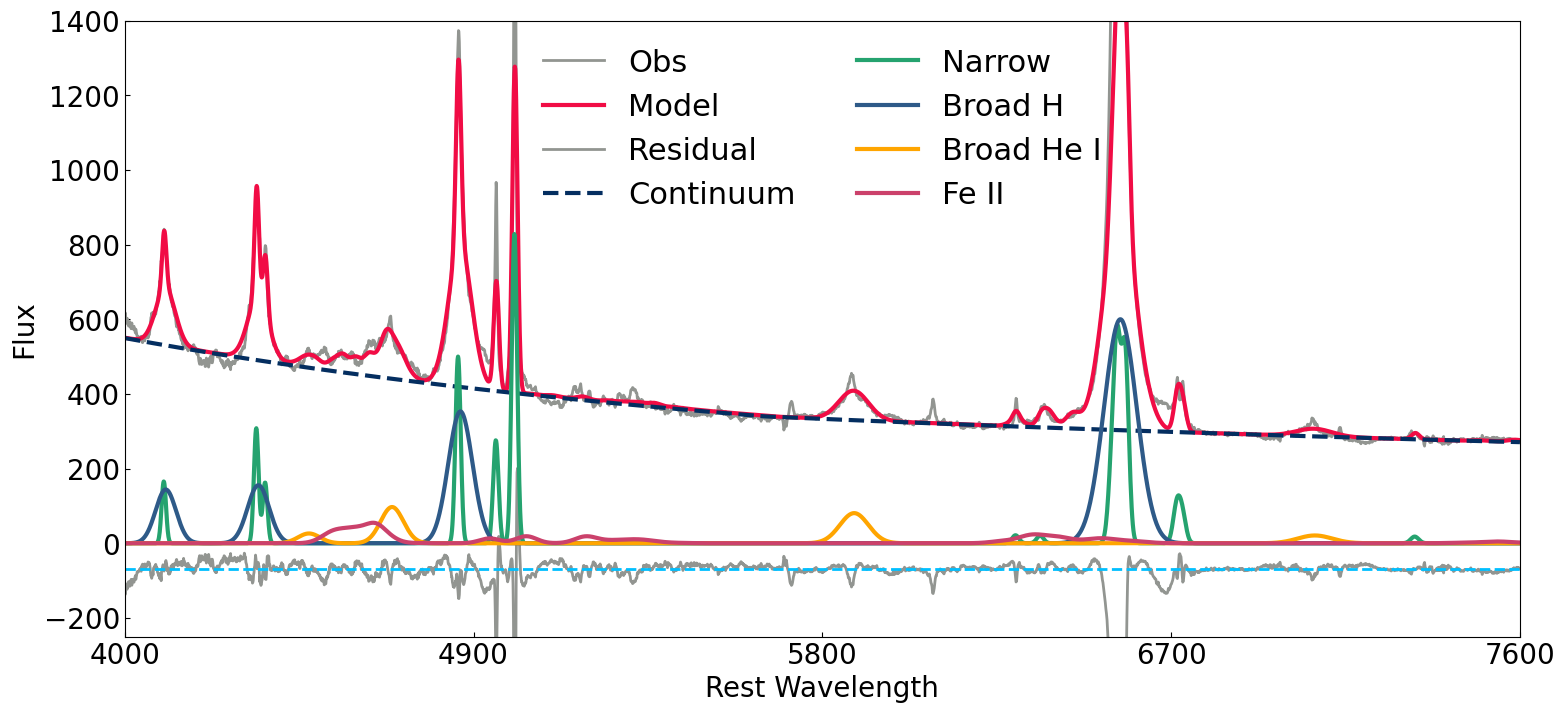

In [36]:
plt.style.context(['nature', 'notebook'])

plt.figure(figsize=(18,8))

plt.plot(s2.wave, s2.flux, color="#929591", label='Obs', lw=2)

plt.plot(s2.wave,
         model2(s2.wave),
         color="#F10C45",
         label='Model',
         lw=3)

plt.plot(s2.wave,
         model2(s2.wave)-s2.flux-70,
         color="#929591",
         label='Residual',
         lw=2)

plt.axhline(y=-70,
            color='deepskyblue',
            linestyle='--',
            lw=2)

plt.plot(s2.wave,
         cont2(s2.wave),
         '--',
         color="#042E60",
         label='Continuum',
         lw=3)

plt.plot(s2.wave,
         narrow2(s2.wave),
         color="#25A36F",
         label='Narrow',
         lw=3)

plt.plot(s2.wave,
         broad2(s2.wave),
         color="#2E5A88",
         label='Broad H',
         lw=3)

plt.plot(s2.wave,
         he2(s2.wave),
         color="orange",
         label='Broad He I',
         lw=3)

plt.plot(s2.wave,
         fe2(s2.wave),
         color="#CB416B",
         label='Fe II',
         lw=3)

plt.xlabel('Rest Wavelength',fontsize=20)
plt.ylabel('Flux',fontsize=20)
plt.xlim(4000,7000)
plt.ylim(-250,1400)
plt.tick_params(which='both', direction="in")
plt.yticks(fontsize=20)
plt.xticks(np.arange(4000, 8000, step=900),fontsize=20)
plt.legend(loc='upper center',  prop={'size': 22}, frameon=False, ncol=2)

plt.savefig('fantasy_object2.pdf')

## Tutorial Fit Results

The best-fit parameters obtained from the tutorial model are shown below.

These values provide a baseline reference before performing parameter tuning and model refinement.

In [27]:
print(s2.gres.format())

Method                = levmar
Statistic             = chi2
Initial fit statistic = 45829
Final fit statistic   = 45369.8 at function evaluation 1078
Data points           = 3010
Degrees of freedom    = 2958
Probability [Q-value] = 0
Reduced statistic     = 15.338
Change in statistic   = 459.197
   brokenpowerlaw.refer   5690         +/- 16.531      
   brokenpowerlaw.ampl   338.755      +/- 1.01845     
   brokenpowerlaw.index1   -1.37823     +/- 0.00670809  
   brokenpowerlaw.index2   0.603718     +/- 0.00914451  
   br.amp_Hd_4102   152.077      +/- 2.63059     
   br.amp_Hg_4340   168.118      +/- 2.89527     
   br.amp_Hb_4861   379.064      +/- 2.45993     
   br.amp_Ha_6563   600          +/- 4.66442     
   br.offs_kms    254.518      +/- 5.42913     
   br.fwhm        4319.02      +/- 16.5177     
   nr_OIII5007.ampl   873.348      +/- 5.58323     
   nr_OIII5007.offs_kms   0            +/- 1.72771     
   nr_OIII5007.fwhm   951.697      +/- 4.0949      
   nr_NII6584.ampl   5

## Spectral Decomposition

The fitted spectrum is decomposed into the following components:

- Continuum emission
- Broad hydrogen emission lines
- Narrow emission lines
- Fe II emission complex
- Helium emission lines

The comparison between the observed spectrum and the fitted model allows us to evaluate the quality of the decomposition.

In [28]:
model2

<BinaryOpModel model instance 'brokenpowerlaw + br + nr_OIII5007 + nr_OIII4958 + nr_NII6584 + nr_NIII6548 + nr_[OIII]_4363 + nr_[OI]_6300 + nr_[OI]_6363 + nr_[SII]_6716 + nr_[SII]_6730 + nr_[OII]_7330 + nr_Hd_4101 + nr_Hg_4340 + nr_Hb_4861 + nr_Ha_6562 + feii + he'>

# Tuned Model for Object 2

The initial fit provided optimized parameter estimates for the broad hydrogen, helium, and Fe II components.

These values were used as improved starting parameters for a second fit in order to test whether the spectral decomposition could be improved.

The tuned model is compared against the baseline tutorial model.

In [29]:
cont2 = continuum(
    s2,
    min_refer=5650,
    refer=5700,
    max_refer=5750
)
broad2 = create_fixed_model(
    ['hydrogen.csv'],
    name='br',

    fwhm=4500,
    min_fwhm=2500,
    max_fwhm=8000
)

he2 = create_fixed_model(
    ['helium.csv'],
    name='he',
    fwhm=3000,
    min_fwhm=1000,
    max_fwhm=7000
)

narrow2 = create_tied_model(
    name='OIII5007',
    files=['narrow_basic.csv','hydrogen.csv'],
    prefix='nr',

    fwhm=1000,

    min_offset=-200,
    max_offset=500,

    min_fwhm=700,
    max_fwhm=1500,

    fix_oiii_ratio=True,
    position=5006.803341,

    included=True,

    min_amplitude=0.2
)

fe2 = create_feii_model(
    name='feii',

    fwhm=2200,

    min_fwhm=1000,
    max_fwhm=4000,

    offset=0,

    min_offset=-3000,
    max_offset=3000
)
model2_tuned = cont2 + broad2 + narrow2 + fe2 + he2

## Tuned Fit Results

After adjusting the model parameters, the fitting procedure was repeated.

The optimized parameters obtained from the tuned model are listed below and can be compared with the tutorial model results.

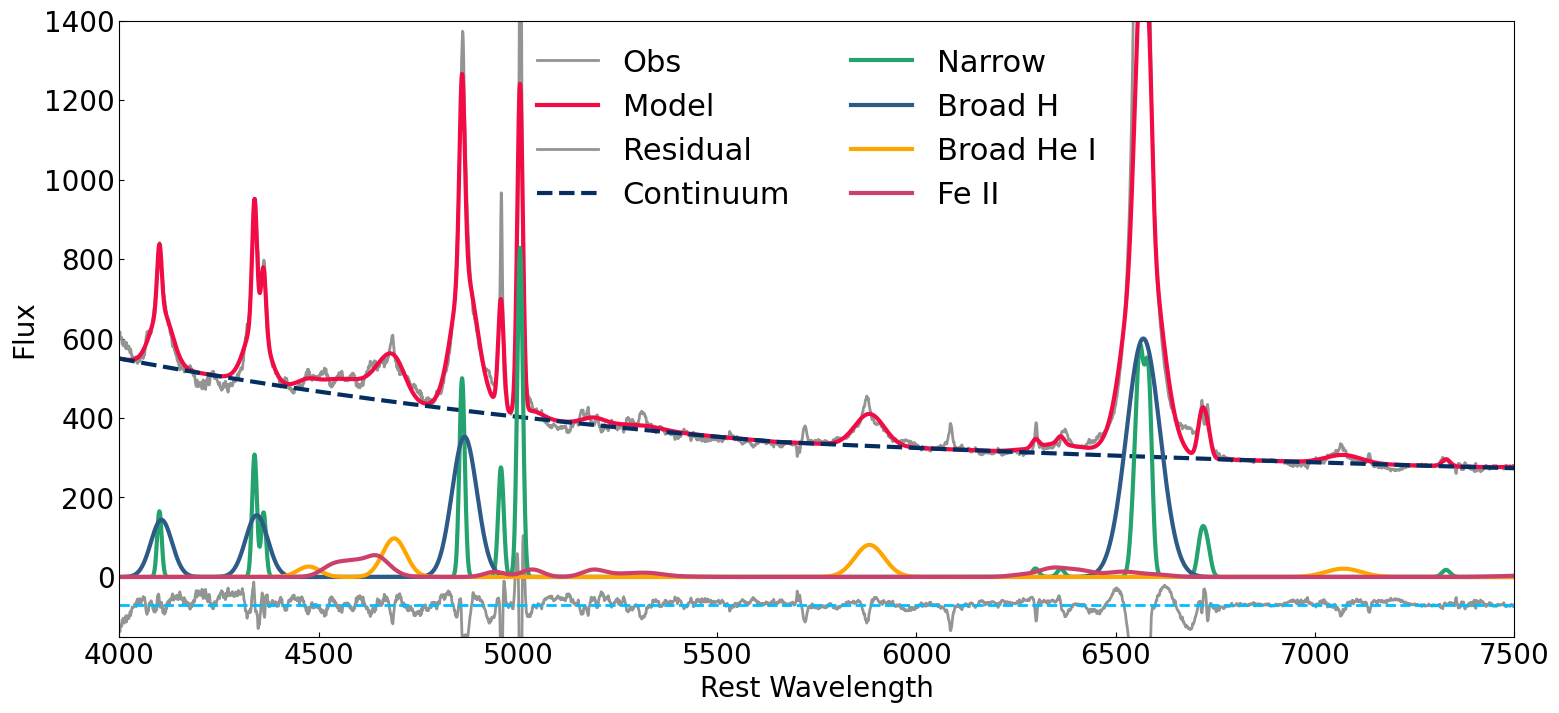

In [35]:
plt.style.context(['nature', 'notebook'])

plt.figure(figsize=(18,8))

plt.plot(s2.wave, s2.flux, color="#929591", label='Obs', lw=2)

plt.plot(s2.wave,
         model2_tuned(s2.wave),
         color="#F10C45",
         label='Model',
         lw=3)

plt.plot(s2.wave,
         model2_tuned(s2.wave)-s2.flux-70,
         color="#929591",
         label='Residual',
         lw=2)

plt.axhline(y=-70,
            color='deepskyblue',
            linestyle='--',
            lw=2)

plt.plot(s2.wave,
         cont2(s2.wave),
         '--',
         color="#042E60",
         label='Continuum',
         lw=3)

plt.plot(s2.wave,
         narrow2(s2.wave),
         color="#25A36F",
         label='Narrow',
         lw=3)

plt.plot(s2.wave,
         broad2(s2.wave),
         color="#2E5A88",
         label='Broad H',
         lw=3)

plt.plot(s2.wave,
         he2(s2.wave),
         color="orange",
         label='Broad He I',
         lw=3)

plt.plot(s2.wave,
         fe2(s2.wave),
         color="#CB416B",
         label='Fe II',
         lw=3)

plt.xlabel('Rest Wavelength',fontsize=20)
plt.ylabel('Flux',fontsize=20)
plt.xlim(4000,7000)
plt.ylim(-150,1400)
plt.tick_params(which='both', direction="in")
plt.yticks(fontsize=20)
plt.xticks(np.arange(4000, 8000, step=500),fontsize=20)
plt.legend(loc='upper center',  prop={'size': 22}, frameon=False, ncol=2)

plt.savefig('fantasy_object2_fit.pdf')

In [31]:
s2.fit(model2_tuned, ntrial=2)

print(s2.gres.format())

iteration:  1
iteration:  2
Method                = levmar
Statistic             = chi2
Initial fit statistic = 44406.2
Final fit statistic   = 43049.9 at function evaluation 1042
Data points           = 3010
Degrees of freedom    = 2958
Probability [Q-value] = 0
Reduced statistic     = 14.5537
Change in statistic   = 1356.29
   brokenpowerlaw.refer   5650         +/- 22.848      
   brokenpowerlaw.ampl   339.911      +/- 1.24549     
   brokenpowerlaw.index1   -1.39138     +/- 0.0102552   
   brokenpowerlaw.index2   0.624834     +/- 0.0123184   
   br.amp_Hd_4102   143.937      +/- 3.06955     
   br.amp_Hg_4340   155.416      +/- 3.88439     
   br.amp_Hb_4861   353.163      +/- 2.32814     
   br.amp_Ha_6563   600          +/- 4.4009      
   br.offs_kms    293.053      +/- 5.24797     
   br.fwhm        4538.87      +/- 16.1724     
   nr_OIII5007.ampl   828.287      +/- 5.45275     
   nr_OIII5007.offs_kms   -80.4064     +/- 1.78914     
   nr_OIII5007.fwhm   984.395      +/- 4.45

In [32]:
model2_tuned

<BinaryOpModel model instance 'brokenpowerlaw + br + nr_OIII5007 + nr_OIII4958 + nr_NII6584 + nr_NIII6548 + nr_[OIII]_4363 + nr_[OI]_6300 + nr_[OI]_6363 + nr_[SII]_6716 + nr_[SII]_6730 + nr_[OII]_7330 + nr_Hd_4101 + nr_Hg_4340 + nr_Hb_4861 + nr_Ha_6562 + feii + he'>

# Model Comparison

The tutorial model and tuned model were compared using the reduced chi-square statistic.

A lower reduced chi-square value indicates a better representation of the observed spectrum.

| Model | Reduced χ² |
|----------|----------|
| Tutorial Model | 15.33 |
| Tuned Model | 14.55 |

The tuned model produced a slightly lower reduced χ² value and was therefore adopted as the preferred solution for Object B.

# Physical Interpretation

The fitted spectrum shows:

- Strong broad Balmer emission lines
- Very strong [O III] emission
- Significant narrow forbidden emission lines
- Detectable Fe II emission
- Broad He I emission

The broad Hβ component has a FWHM of approximately 4281 km/s, confirming the Type 1 AGN classification.

The presence of broad Balmer lines, Fe II emission, and helium emission further supports the active galactic nucleus interpretation.

# Comparison of Object A and Object B

| Object | Reduced χ² | Remarks |
|----------|----------|----------|
| Object A | 15.94 | Better fit quality |
| Object B | 14.55 | More complex spectrum |

Object A produced a significantly better fit than Object B.

The larger reduced χ² obtained for Object B indicates that the source contains stronger or more complex spectral features that are not fully described by the adopted model configuration.

# Conclusion

In this project, the FANTASY spectral fitting package was used to perform spectral decomposition of two Type 1 AGN candidates.

For both objects:

- Galactic extinction correction was applied.
- Host galaxy contamination was estimated and removed.
- Spectra were fitted using continuum, broad-line, narrow-line, Fe II, and helium components.
- Model parameters were optimized through iterative fitting.

Object A achieved the best overall fit with a reduced χ² of approximately 15.94.

Object B showed a more complex spectral structure and a higher reduced χ² value, indicating that additional model refinement may be required.

Overall, the analysis demonstrates that FANTASY is an effective tool for decomposing AGN spectra and studying the physical properties of emission-line regions.